<div align="center">

**CIVE 7100: Time Series and Geospatial Data Science**

Northeastern University

</div>

**Final Project: Forecasting and Model Validation**

Juan Cruz Ferreyra

---

## Methodology and Objectives

This notebook implements the final forecasting phase using the SARIMA(1,1,1)(1,0,0)â‚‡ model selected in the previous analysis. We evaluate forecast performance under two scenarios that reflect different operational contexts:

**Multi-step forecasting** generates predictions for the entire test period (January-February 2026) in a single forecast run without incorporating actual observed values as they become available. This approach simulates planning scenarios where decisions must be made based on forecasts alone, such as monthly resource allocation or long-range capacity planning. Multi-step forecasts test the model's ability to project demand forward without adaptive corrections.

**One-step-ahead recursive forecasting** updates the model with each day's actual demand before forecasting the next day. This reflects operational rebalancing use cases where yesterday's demand is known by the time tonight's rebalancing decisions are made. The recursive approach allows the model to adapt to recent shocks (weather events, holidays, operational disruptions) through its MA component, providing more accurate short-term forecasts at the cost of requiring daily data updates.

We compare both approaches to understand the trade-off between forecast horizon and accuracy, then validate the selected model through residual diagnostics. If residuals approximate white noise, the model successfully captured systematic temporal structure. Persistent patterns in residuals indicate unmodeled structure requiring explanation.

In [11]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

from bluebikes_forecasting.config import LOCAL_DATA_DIR
from bluebikes_forecasting.plots import (
    COLORS,
    plot_daily_longterm_split,
    plot_daily_longterm
)

In [12]:
timeseries_dir = LOCAL_DATA_DIR / "processed" / "trips"

station_name = "B32003"
station_file = timeseries_dir / f"station/{station_name}_morning_demand.csv"
df_station = pd.read_csv(station_file)

## Data Preparation and Cross-Validation Strategy

We use expanding window cross-validation with four quarterly splits throughout 2025 to evaluate forecast performance across seasonal conditions. Each split trains on all data up to the split date and tests on the subsequent two months (approximately 60 days). The four splits test spring (April-May), summer (July-August), fall (October-November), and winter (January-February 2026) forecast accuracy, providing robust performance assessment across varied weather conditions, holidays, and demand patterns. This approach validates model stability while respecting temporal ordering.


SPLIT 1



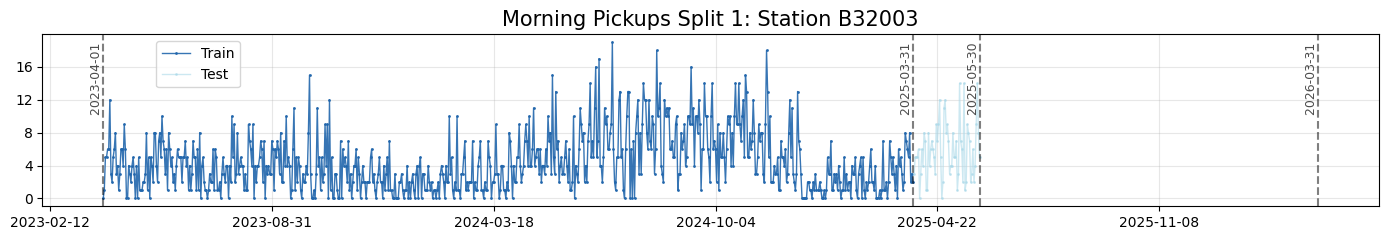

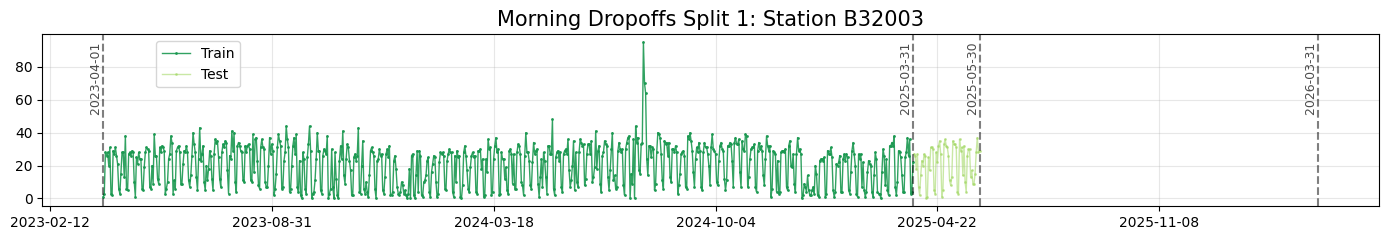


SPLIT 2



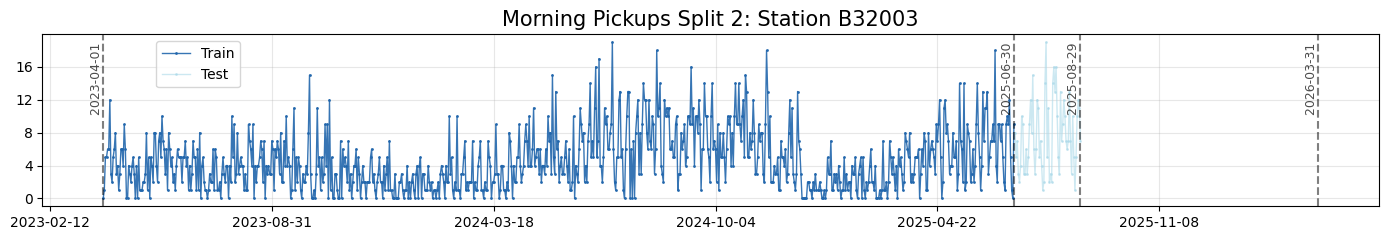

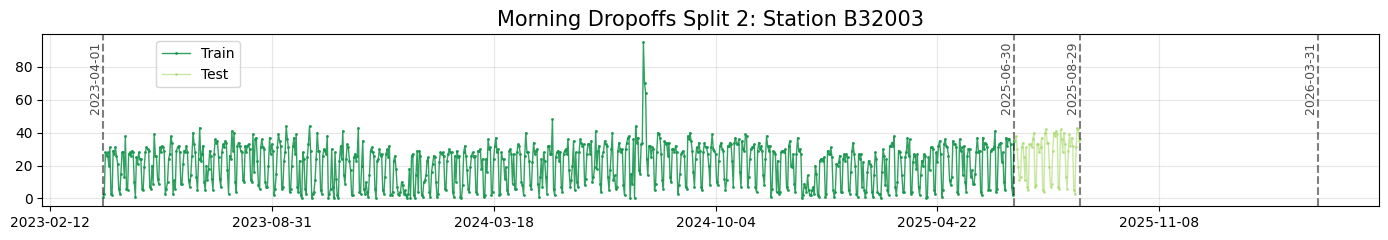


SPLIT 3



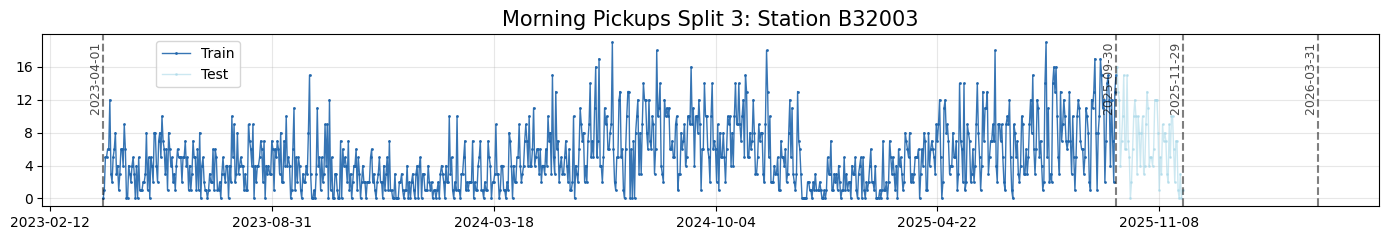

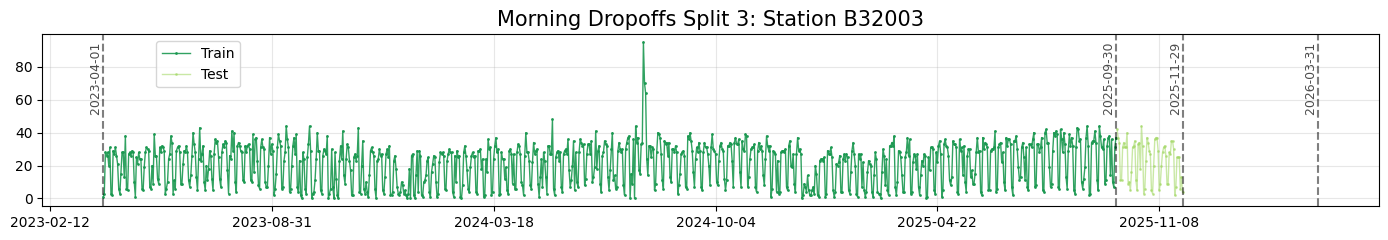


SPLIT 4



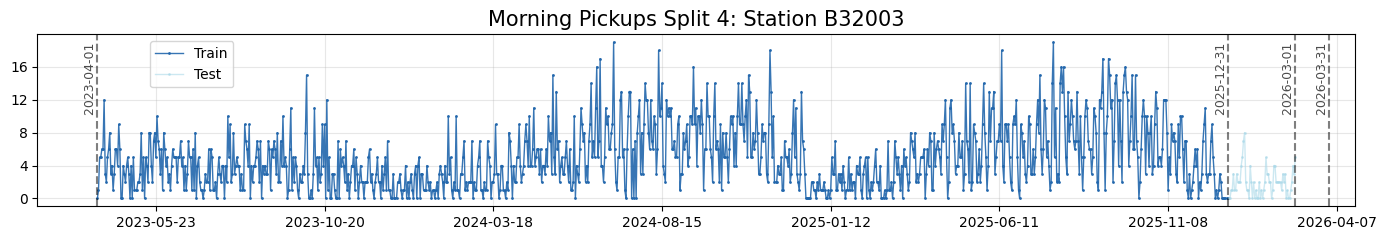

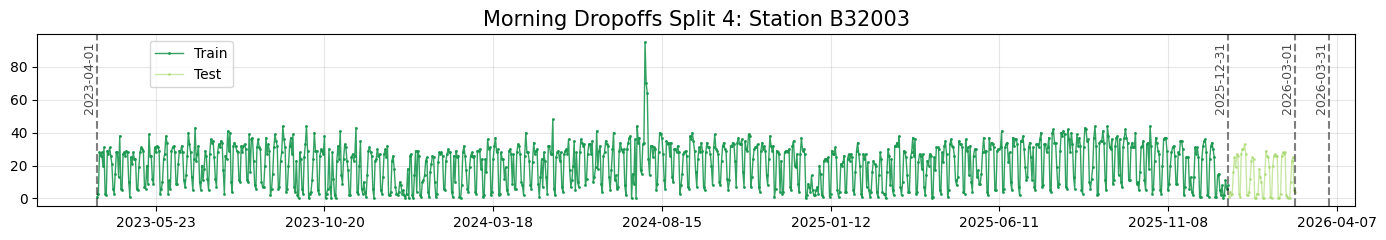

In [13]:
df_station["date"] = pd.to_datetime(df_station["date"])

# Define cross-validation splits (quarterly through 2025)
split_dates = [
    pd.Timestamp("2025-03-31"),
    pd.Timestamp("2025-06-30"),
    pd.Timestamp("2025-09-30"),
    pd.Timestamp("2025-12-31"),
]

cv_splits = []
for split_date in split_dates:
    train = df_station[df_station["date"] <= split_date]

    test_start = split_date + pd.Timedelta(days=1)
    test_end = test_start + pd.Timedelta(days=59)  # ~2 months
    test = df_station[(df_station["date"] >= test_start) & (df_station["date"] <= test_end)]

    discarded = df_station[df_station["date"] > test_end]

    cv_splits.append(
        {"split_date": split_date, "train": train, "test": test, "discarded": discarded}
    )

# Plot each split
for idx, split in enumerate(cv_splits, 1):
    print(f"\n{'='*60}")
    print(f"SPLIT {idx}")
    print(f"{'='*60}\n")

    train_indexed = split["train"].set_index("date")
    test_indexed = split["test"].set_index("date")
    discarded_indexed = split["discarded"].set_index("date")

    df_list = (
        [train_indexed, test_indexed, discarded_indexed]
        if len(discarded_indexed) > 0
        else [train_indexed, test_indexed]
    )

    # Pickups
    plot_daily_longterm_split(
        df_list=df_list,
        columns_to_plot=["morning_pickups"],
        title=f"Morning Pickups Split {idx}: Station {station_name}",
        split_labels=["Train", "Test"],
        color_list=[[COLORS[7], COLORS[6]]],
        figsize=(14, 2.5),
    )

    # Dropoffs
    plot_daily_longterm_split(
        df_list=df_list,
        columns_to_plot=["morning_dropoffs"],
        title=f"Morning Dropoffs Split {idx}: Station {station_name}",
        split_labels=["Train", "Test"],
        color_list=[[COLORS[5], COLORS[4]]],
        figsize=(14, 2.5),
    )

## Multi-Step Forecast Evaluation

We first evaluate the model's ability to generate extended forecasts without intermediate data updates. For each cross-validation split, we fit SARIMA(1,1,1)(1,0,0)₇ on training data and forecast the entire test period (approximately 60 days ahead) in a single prediction run. This simulates planning scenarios where decisions must be made based on forecasts alone, such as monthly resource allocation or capacity planning, without the benefit of observed demand data as it becomes available. Multi-step forecasts test the model's pure forecasting capability and reveal how prediction accuracy degrades over longer horizons as MA components lose adaptive capacity and uncertainty compounds.

In [14]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


def train_sarima(train_data, order=(1, 1, 1), seasonal_order=(1, 0, 0, 7)):
    """Train SARIMA model on training data."""
    model = SARIMAX(train_data.dropna(), order=order, seasonal_order=seasonal_order)
    return model.fit(disp=False)


def evaluate_forecast(model, test_df, series_name, split_idx):
    """Generate forecast and calculate performance metrics."""
    actual_col = f'morning_{series_name}'
    
    # Forecast
    forecast = model.forecast(steps=len(test_df))
    actual = test_df[actual_col].values
    errors = actual - forecast
    
    # Create results dataframe
    results_df = test_df[['date', actual_col]].copy()
    results_df['forecast'] = forecast
    results_df['error'] = errors
    results_df = results_df.rename(columns={actual_col: 'actual'})
    
    # Calculate metrics
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    
    return {
        "split_idx": split_idx,
        "model": model,
        "results_df": results_df,  # DataFrame with date, actual, forecast, error
        "mae": mae,
        "rmse": rmse,
    }


cv_results = {"pickups": [], "dropoffs": []}

for split_idx, split in enumerate(cv_splits):
    print(f"Fitting Split {split_idx + 1}...")

    for series_name in ["pickups", "dropoffs"]:
        # Train
        model = train_sarima(split["train"][f"morning_{series_name}"])

        # Evaluate
        result = evaluate_forecast(model, split["test"], series_name, split_idx)

        cv_results[series_name].append(result)

Fitting Split 1...
Fitting Split 2...
Fitting Split 3...
Fitting Split 4...


We evaluate forecast accuracy using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). MAE provides an interpretable average deviation in trips, while RMSE penalizes larger errors more heavily. Both metrics are calculated on the original scale (trip counts) for direct operational interpretation.

In [15]:
# Extract metrics into DataFrames
metrics_dfs = {}

for series_name in ["pickups", "dropoffs"]:
    metrics = pd.DataFrame(
        [
            {
                "Split": i + 1,
                "MAE": r["mae"],
                "RMSE": r["rmse"],
                "Avg_Actual": r["results_df"]["actual"].mean(),
            }
            for i, r in enumerate(cv_results[series_name])
        ]
    )

    # Add average row
    metrics.loc[len(metrics)] = [
        "Avg",
        metrics["MAE"].mean(),
        metrics["RMSE"].mean(),
        metrics["Avg_Actual"].mean(),
    ]

    # Rename columns with series prefix
    metrics.columns = ["Split"] + [f"{series_name.title()}_{col}" for col in metrics.columns[1:]]
    metrics_dfs[series_name] = metrics

# Combine side by side
summary_table = metrics_dfs["pickups"].merge(metrics_dfs["dropoffs"], on="Split")

print("=" * 80)
print("MULTI-STEP FORECAST PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_table.to_string(index=False, float_format="%.2f"))

MULTI-STEP FORECAST PERFORMANCE SUMMARY
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         3.12          4.05                5.78          8.77           9.73                21.10
    2         3.48          4.37                7.62         11.16          12.37                26.60
    3         3.79          4.59                6.88          9.45          10.93                22.90
    4         1.39          1.76                1.97         10.76          12.23                13.92
  Avg         2.95          3.69                5.56         10.04          11.32                21.13


The model achieves consistent performance across splits for pickup demand (average MAE = 2.94 trips, RMSE = 3.69 trips), representing approximately 53% error relative to mean demand (5.55 trips). Dropoff demand exhibits higher absolute error (average MAE = 10.01 trips, RMSE = 11.30 trips) but similar relative performance at 47% of mean demand (21.17 trips). The comparable error-to-mean ratios indicate consistent model performance across both series despite different demand scales.

Split 4 (winter, January-February 2026) shows the lowest absolute error but the highest relative error for both series. Pickup MAE of 1.37 trips represents 71% of mean demand (1.92 trips), compared to summer's 46% (3.48 MAE / 7.62 mean). Similarly, dropoff error remains disproportionately high relative to suppressed winter demand. This indicates the model struggles more during winter conditions despite lower absolute error values. The winter test period was characterized by heavy snowstorms that severely suppressed ridership for extended periods. In multi-step forecasting mode, the model cannot adapt to these extreme weather shocks as they occur. The MA component, which would normally adjust predictions based on yesterday's forecast error, operates with zero error terms in multi-step mode since no actual observations are incorporated. This limitation becomes critical during abrupt demand changes where one-step-ahead forecasting would adaptively correct using recent errors, but multi-step forecasting propagates predictions based solely on historical seasonal patterns without real-time adjustment capability.


SPLIT 1 - ACTUAL VS FORECAST



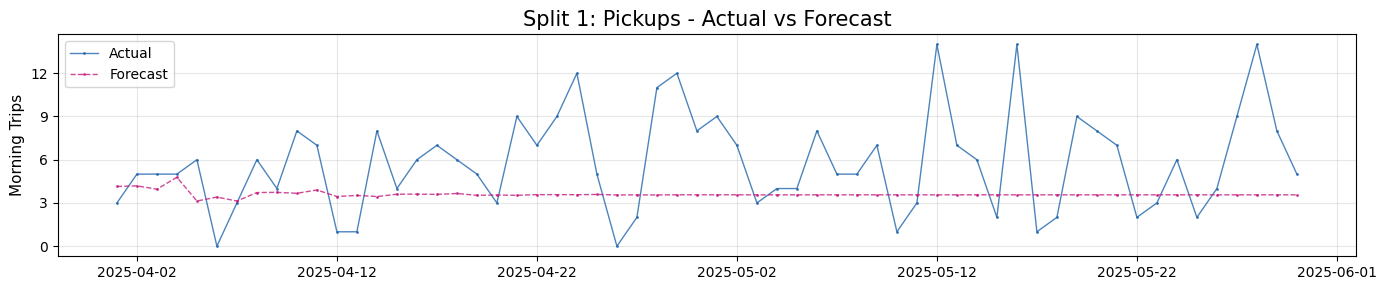

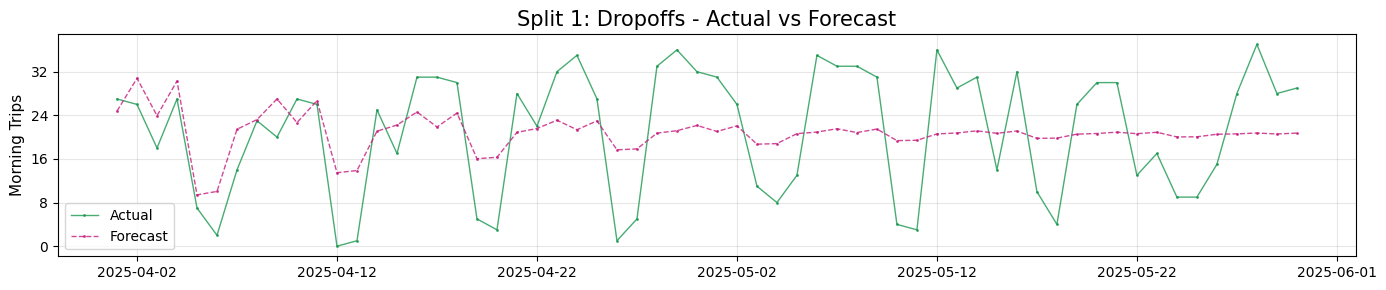


SPLIT 2 - ACTUAL VS FORECAST



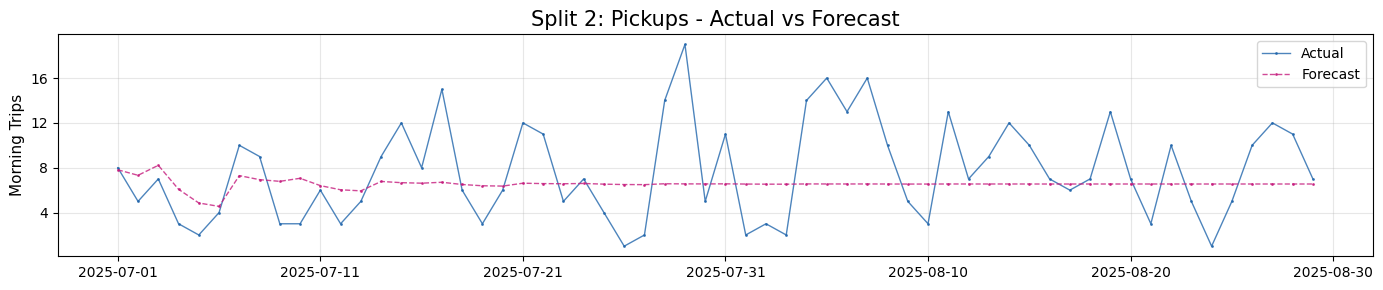

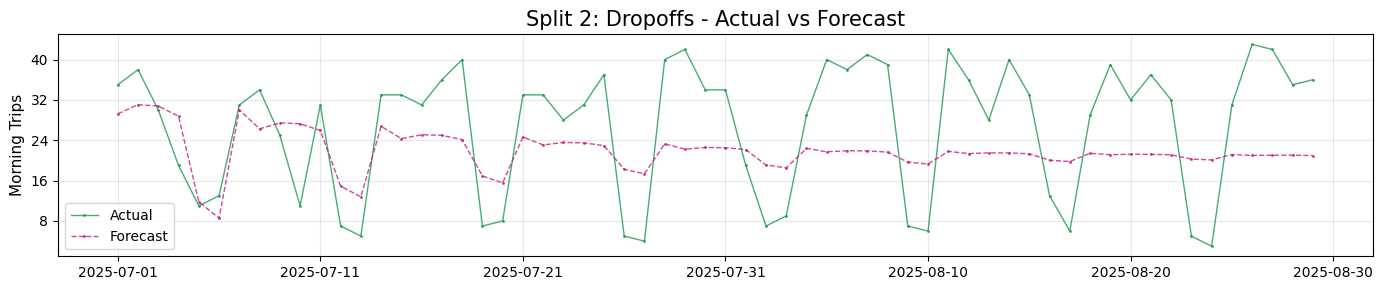


SPLIT 3 - ACTUAL VS FORECAST



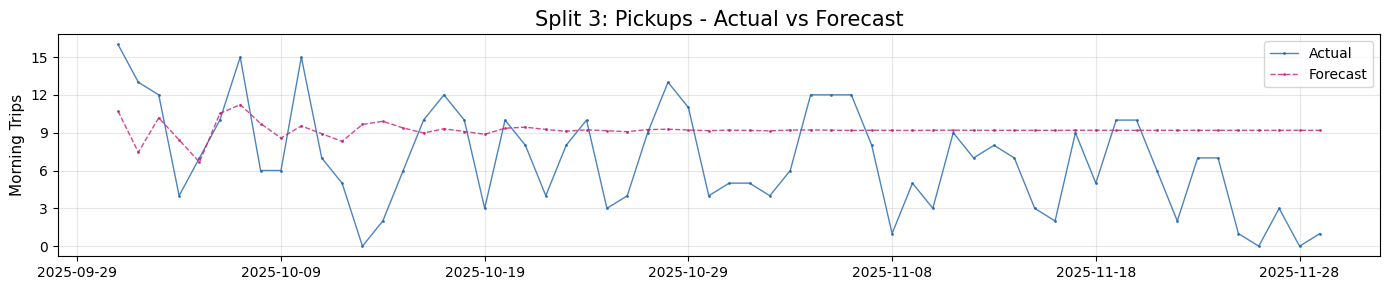

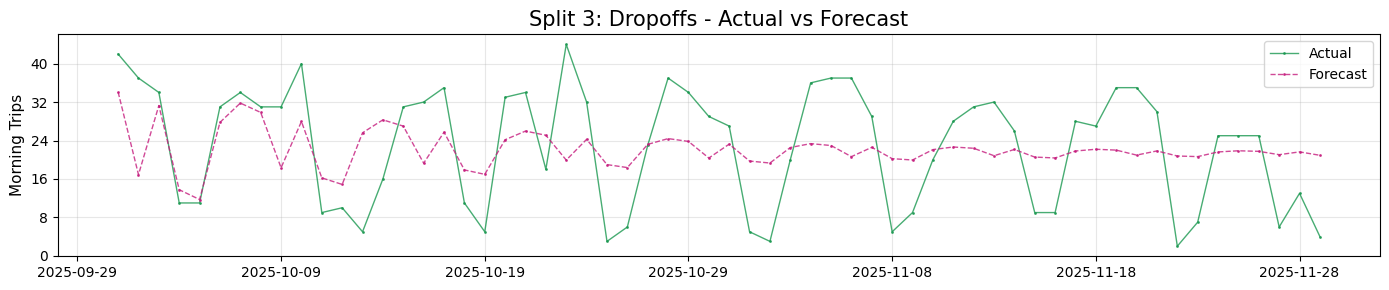


SPLIT 4 - ACTUAL VS FORECAST



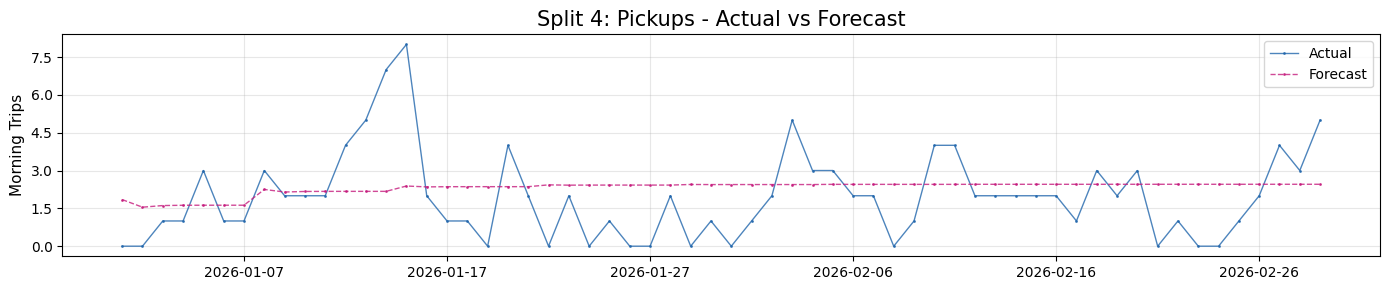

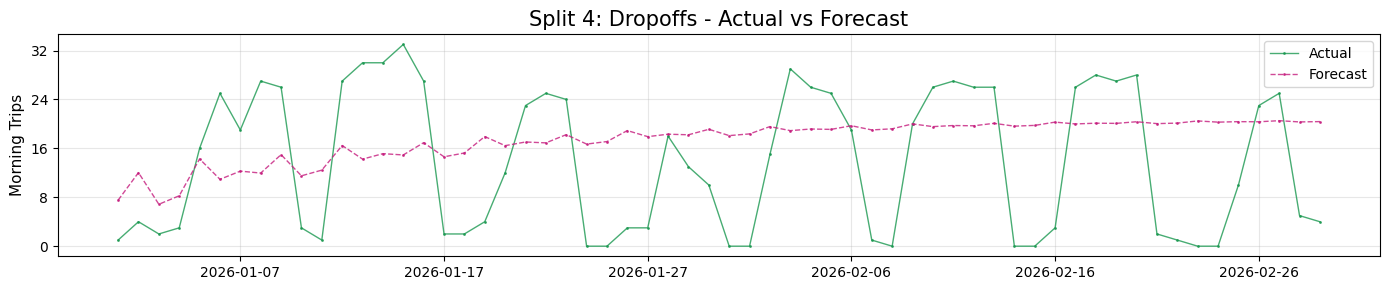

In [16]:
# Plot actual vs forecast for each split
for split_idx in range(len(cv_splits)):
    print(f"\n{'='*60}")
    print(f"SPLIT {split_idx + 1} - ACTUAL VS FORECAST")
    print(f"{'='*60}\n")

    for series_name in ["pickups", "dropoffs"]:
        results_df = cv_results[series_name][split_idx]["results_df"].set_index("date")

        actual_color = COLORS[7] if series_name == "pickups" else COLORS[5]

        plot_daily_longterm(
            results_df,
            columns_to_plot=["actual", "forecast"],
            title=f"Split {split_idx + 1}: {series_name.title()} - Actual vs Forecast",
            ylabel="Morning Trips",
            color_list=[actual_color, COLORS[1]],
            linestyle_list=["-", "--"],
            legend_labels=["Actual", "Forecast"],
            figsize=(14, 3),
        )

**Pickup Demand Patterns:**

The pickup forecasts exhibit a characteristic multi-step decay pattern across all splits. During the first week, the model attempts to reconstruct demand dynamics, showing oscillations around actual values. Beyond week one, predictions converge to a near-constant value that varies by split but remains stable throughout the remaining forecast horizon. This convergence reflects the model's reliance on the final training period's baseline without annual seasonal components. The SARIMA(1,1,1)(1,0,0)₇ specification captures weekly patterns but cannot adjust for month-to-month seasonal transitions in baseline demand.

The convergence value varies systematically by season based on the training period's endpoint. Split 1 (April-May test) trains through late winter (March), when demand is suppressed, causing forecasts to converge below actual spring values as ridership recovers. Conversely, Split 3 (October-November test) trains through late summer (September), when demand remains elevated, causing forecasts to converge above actual fall values as ridership declines. This asymmetry demonstrates how multi-step forecasts anchor to recent training patterns. Without explicit annual seasonality, the model projects the most recent weekly baseline forward indefinitely, unable to anticipate seasonal transitions between winter suppression, spring recovery, summer peaks, and fall decline.

Actual demand during spring test period increases progressively, but the model's flat convergence pattern fails to track this growth. This limitation reflects the trade-off in model selection: incorporating annual seasonality (s=365) would enable the model to anticipate seasonal transitions but requires longer historical data and increases model complexity substantially.

**Dropoff Demand Patterns:**

Dropoff forecasts display more persistent weekly oscillations, maintaining recognizable weekday-weekend patterns through approximately four weeks before converging to stable values. This extended dynamic range reflects dropoffs' stronger weekly structure (from `04_classical_model_selection.ipynb`: ACF ρ₇ = 0.63 vs pickups' 0.27) and more stable baseline across seasons at this station. The model successfully captures short-term weekly patterns across most splits, though oscillation amplitude diminishes as forecast horizon extends beyond the MA component's one-step influence.

Split 4 (January-February 2026 test) diverges from this pattern, showing minimal weekly structure and immediate convergence to low values. The training period's final weeks (late December 2025) experienced unusually suppressed demand due to snow and below-average temperatures, obscuring typical weekly patterns in the training data. The model's multi-step forecast propagates this atypical suppressed baseline without adapting to January's actual conditions, illustrating how extreme events in the final training window disproportionately influence extended forecasts when annual patterns are not explicitly modeled.

**General Observations:**

Forecast accuracy degrades substantially beyond one week across all splits and both series. The model demonstrates reasonable short-horizon performance but converges to training-period-dependent constant predictions for longer horizons. This behavior results from two limitations: the absence of annual seasonal modeling (preventing anticipation of seasonal transitions) and the mechanics of multi-step forecasting, where MA components cannot adapt to evolving conditions since forecast errors are set to zero beyond one step. The systematic over-prediction or under-prediction based on training period seasonality confirms that incorporating annual cycles or implementing one-step-ahead recursive forecasting would substantially improve operational performance for planning horizons beyond one week.

## One-Step-Ahead Recursive Forecast Evaluation

We now evaluate the model under the operational scenario where yesterday's actual demand is available before forecasting tomorrow. For bike-share rebalancing operations, overnight decisions (2:00-6:00 AM) occur after the prior day's demand is known, making one-step-ahead forecasting the realistic deployment mode. This approach allows the MA component to function as designed: yesterday's forecast error adjusts today's prediction, enabling the model to adapt to recent shocks such as weather events, holidays, or operational disruptions.

For each cross-validation split, we maintain the same fitted SARIMA(1,1,1)(1,0,0)₇ model used in multi-step evaluation but update predictions recursively. Each day's forecast incorporates the previous day's actual observation, allowing the AR component to use real lagged demand and the MA component to apply the most recent forecast error. This simulates operational deployment where models are retrained periodically (weekly or monthly) but generate daily forecasts using live data updates between retraining cycles. The recursive approach tests whether the model's adaptive capacity through MA error correction substantially improves accuracy compared to pure multi-step projection.

In [17]:
def evaluate_forecast_onestep(fitted_model, test_df, series_name, split_idx):
    """Generate one-step-ahead recursive forecasts without refitting."""
    actual_col = f"morning_{series_name}"
    actual_values = test_df[actual_col].values

    # Rolling forecast
    updated_model = fitted_model
    forecasts = []
    errors = []

    for t in range(len(actual_values)):
        # One-step ahead prediction
        pred = updated_model.forecast(steps=1).values[0]
        forecasts.append(pred)

        # Actual observation
        actual = actual_values[t]
        error = actual - pred
        errors.append(error)

        # Update model state with observed value
        updated_model = updated_model.append([actual], refit=False)

    # Build results DataFrame
    results_df = test_df[["date", actual_col]].copy()
    results_df["forecast"] = forecasts
    results_df["error"] = errors
    results_df = results_df.rename(columns={actual_col: "actual"})

    # Calculate metrics
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(np.array(errors) ** 2))

    return {
        "split_idx": split_idx,
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
    }


cv_results_onestep = {"pickups": [], "dropoffs": []}

for series_name in ["pickups", "dropoffs"]:
    for result in cv_results[series_name]:
        # Use already fitted model
        model = result["model"]
        split_idx = result["split_idx"]
        test_df = cv_splits[split_idx]["test"]

        # Evaluate one-step
        result_onestep = evaluate_forecast_onestep(model, test_df, series_name, split_idx)
        cv_results_onestep[series_name].append(result_onestep)

print("One-step-ahead forecasting complete!")

One-step-ahead forecasting complete!


In [18]:
# Extract metrics into DataFrames
metrics_dfs = {}

for series_name in ["pickups", "dropoffs"]:
    metrics = pd.DataFrame(
        [
            {
                "Split": i + 1,
                "MAE": r["mae"],
                "RMSE": r["rmse"],
                "Avg_Actual": r["results_df"]["actual"].mean(),
            }
            for i, r in enumerate(cv_results_onestep[series_name])
        ]
    )
    
    # Add average row
    avg_row = pd.DataFrame([{
        "Split": "Avg",
        "MAE": metrics["MAE"].mean(),
        "RMSE": metrics["RMSE"].mean(),
        "Avg_Actual": metrics["Avg_Actual"].mean()
    }])
    metrics = pd.concat([metrics, avg_row], ignore_index=True)

    # Rename columns with series prefix
    metrics.columns = ["Split"] + [f"{series_name.title()}_{col}" for col in metrics.columns[1:]]
    metrics_dfs[series_name] = metrics

# Combine side by side
summary_table_onestep = metrics_dfs["pickups"].merge(metrics_dfs["dropoffs"], on="Split")

print("=" * 80)
print("ONE-STEP-AHEAD FORECAST PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_table_onestep.to_string(index=False, float_format="%.2f"))

ONE-STEP-AHEAD FORECAST PERFORMANCE SUMMARY
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         2.55          3.26                5.78          5.86           7.39                21.10
    2         3.09          3.72                7.62          6.50           7.98                26.60
    3         3.09          3.73                6.88          6.03           8.47                22.90
    4         1.30          1.68                1.97          6.17           7.82                13.92
  Avg         2.51          3.10                5.56          6.14           7.92                21.13


One-step-ahead forecasting shows substantial improvement over multi-step forecasting, though the magnitude differs markedly between pickup and dropoff series.

**Pickup Demand:**
The model achieves modest improvement across all splits, with MAE reduction ranging from 10% to 20% (average MAE decreases from 2.94 to 2.50 trips). This limited gain is surprising given that one-step-ahead forecasting benefits from both observed lagged demand (AR component) and yesterday's forecast error (MA component), while multi-step forecasting relies on predicted values and zero error terms. The modest improvement suggests pickup demand's forecast errors are largely driven by factors beyond short-term adaptive capacity, such as unpredictable day-to-day variation or the model's inability to capture annual seasonal transitions that neither AR nor MA components can address.

**Dropoff Demand:**
The model demonstrates substantial improvement, with MAE reduction between 35% and 42% across splits (average MAE decreases from 10.01 to 6.15 trips, RMSE from 11.30 to 7.93). This substantial improvement indicates dropoff demand benefits strongly from the MA component's error correction mechanism. The recursive incorporation of yesterday's forecast error allows the model to adapt effectively to recent shocks and evolving patterns, achieving approximately 40% error reduction compared to multi-step forecasting. The contrast with pickup performance suggests dropoff demand exhibits more persistent short-term dependencies that MA(1) can exploit.

We now examine actual versus forecasted time series plots to understand why one-step-ahead forecasting provides differential improvement between pickup and dropoff demand and identify the sources of remaining forecast error in the adaptive mode.


SPLIT 1 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



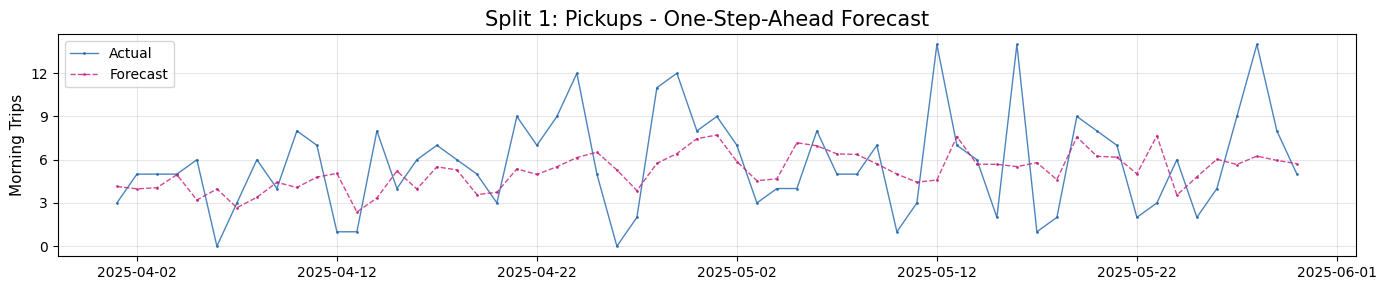

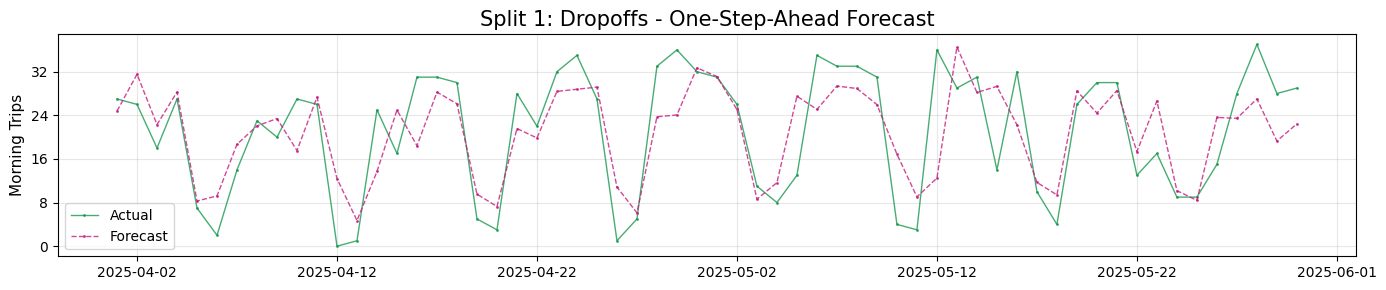


SPLIT 2 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



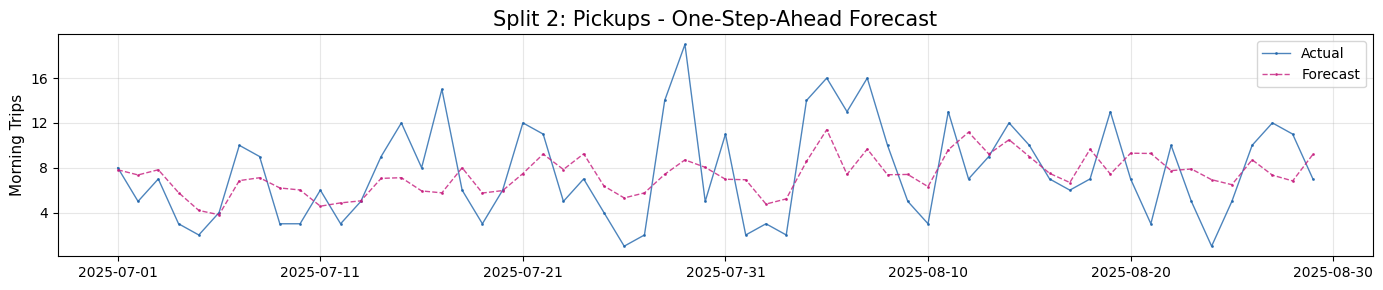

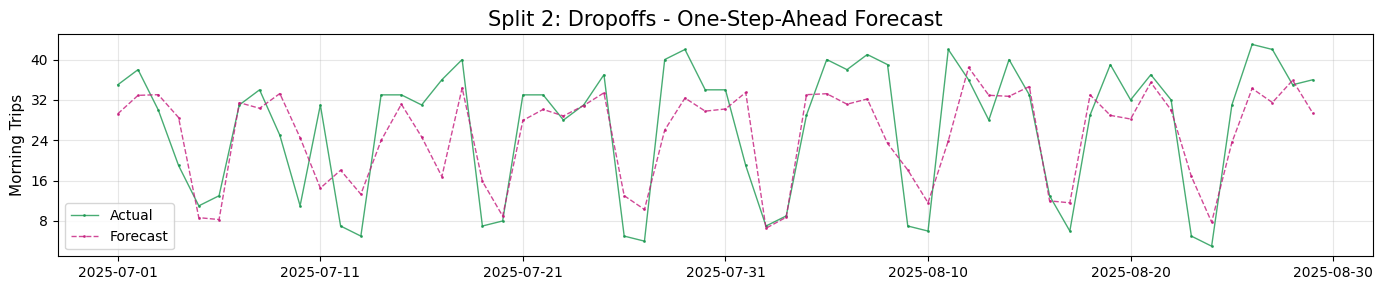


SPLIT 3 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



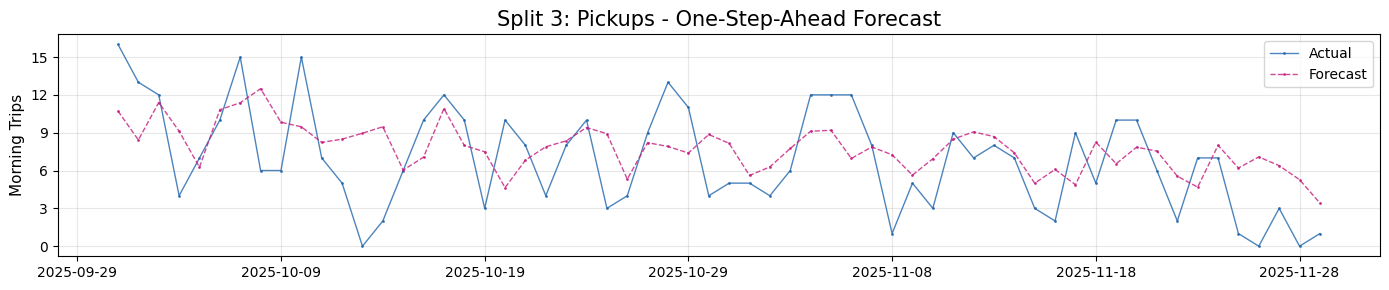

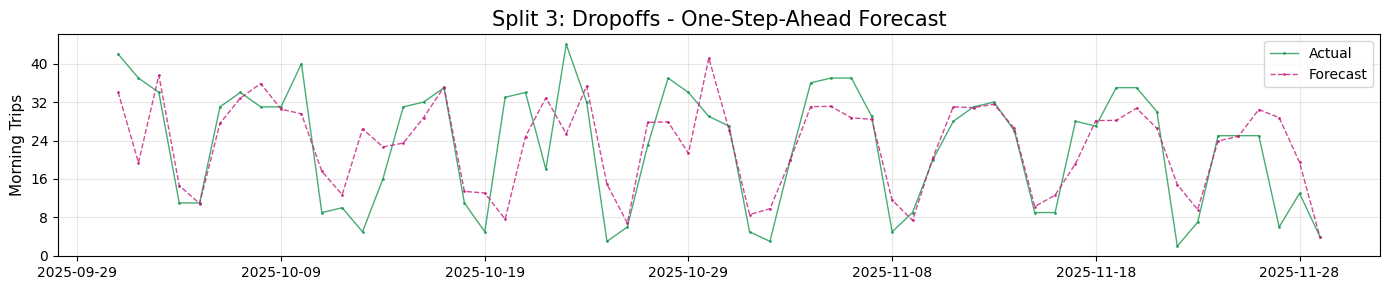


SPLIT 4 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



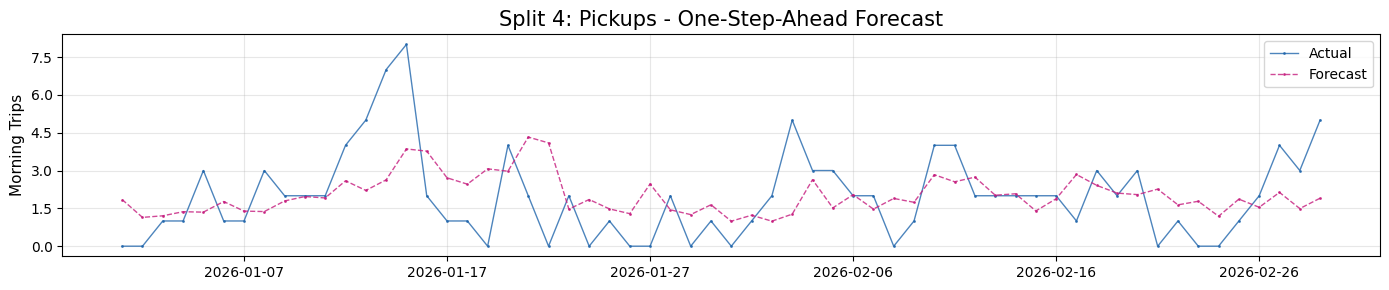

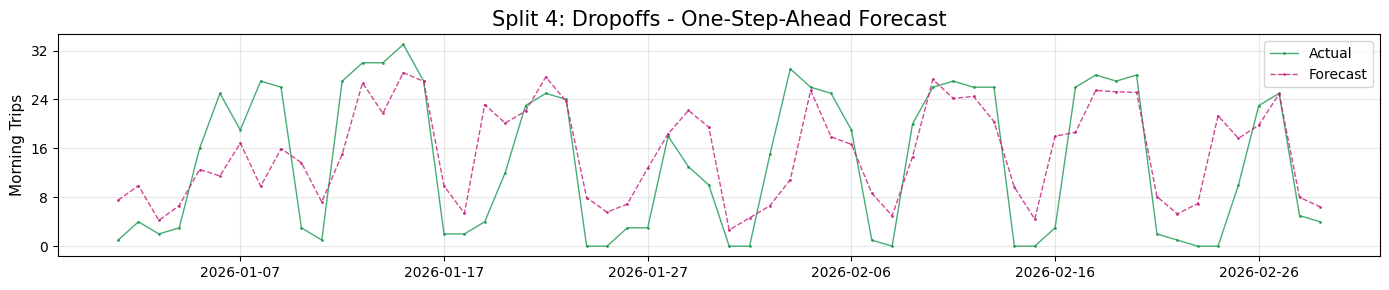

In [19]:
# Plot actual vs forecast for each split (one-step-ahead)
for split_idx in range(len(cv_splits)):
    print(f"\n{'='*60}")
    print(f"SPLIT {split_idx + 1} - ONE-STEP-AHEAD: ACTUAL VS FORECAST")
    print(f"{'='*60}\n")

    for series_name in ["pickups", "dropoffs"]:
        results_df = cv_results_onestep[series_name][split_idx]["results_df"].set_index("date")

        actual_color = COLORS[7] if series_name == "pickups" else COLORS[5]

        plot_daily_longterm(
            results_df,
            columns_to_plot=["actual", "forecast"],
            title=f"Split {split_idx + 1}: {series_name.title()} - One-Step-Ahead Forecast",
            ylabel="Morning Trips",
            color_list=[actual_color, COLORS[1]],
            linestyle_list=["-", "--"],
            legend_labels=["Actual", "Forecast"],
            figsize=(14, 3),
        )

The actual versus forecast plots reveal fundamental differences in series behavior that explain the differential improvement between pickup and dropoff forecasting.

**Dropoff Demand Characteristics:**

Dropoff series exhibit pronounced and stable weekly patterns across all test periods. Weekday values consistently range between 20-30 trips during lower-usage months and 30-40 trips during peak periods, with sharp declines on weekends. This regular oscillation creates a predictable structure that one-step-ahead forecasting captures effectively. The model tracks weekly cycles closely, with forecast errors primarily reflecting amplitude variations rather than pattern misidentification. The strong weekly structure (ACF ρ₇ = 0.63) translates directly into forecast accuracy as the AR and MA components exploit persistent patterns.

**Pickup Demand Characteristics:**

Pickup series show substantially lower volumes (maximums 12-15 trips, minimums 0-3 trips) and weaker cyclical structure. While weekday usage tends to exceed weekend usage, the pattern is frequently disrupted by day-to-day volatility. A single group using bikes on a weekend morning (2-3 additional trips) represents a 50-100% increase relative to typical weekend baseline, masking underlying weekly patterns. The series appears dominated by stochastic variation rather than deterministic cycles, making pattern-based forecasting inherently more challenging. Low absolute values amplify the impact of random fluctuations, preventing clear weekly structure from emerging visually.

**Implications for Forecast Performance:**

The contrasting patterns explain why one-step-ahead forecasting improves dropoff predictions substantially (40% error reduction) but provides limited gains for pickups (10-20% reduction). Dropoffs' stable weekly rhythm allows MA error correction to effectively adjust predictions based on recent deviations from the pattern. Pickups' noise-dominated behavior limits adaptive forecasting benefits—yesterday's error provides less information when underlying patterns are weak and stochastic variation dominates the signal.

This reveals a general forecasting principle for low-volume integer time series: when baseline values approach the scale of random fluctuations (pickups averaging 5-7 trips with 2-3 trip standard deviation), relative forecast errors remain high regardless of model sophistication. The noise-to-signal ratio fundamentally limits achievable accuracy, making demand pooling (aggregating across multiple low-volume stations) or probabilistic forecasting (prediction intervals rather than point estimates) more appropriate for operational planning than attempting precise point forecasts for individual low-volume locations.

## Residual Diagnostics: Model Validation

We examine forecast residuals from the one-step-ahead predictions to validate model adequacy. Residual analysis tests whether the SARIMA specification successfully captured systematic temporal structure, leaving only random unpredictable variation. We use one-step-ahead residuals rather than multi-step because multi-step forecasts exhibit known systematic biases (seasonal anchoring to training period endpoints) that reflect forecast horizon limitations rather than model misspecification. One-step-ahead residuals provide the proper diagnostic for evaluating whether the chosen ARIMA orders and seasonal components adequately represent the data generating process.

If residuals approximate white noise (zero mean, constant variance, no autocorrelation), the model has successfully extracted all predictable patterns. Persistent structure in residuals indicates unmodeled dependencies requiring model refinement or acknowledgment of inherent unpredictability in the series.

In [20]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Analyze residuals per split
for split_idx in range(len(cv_splits)):
    print(f"\n{'='*70}")
    print(f"SPLIT {split_idx + 1} RESIDUAL DIAGNOSTICS")
    print(f"{'='*70}")
    
    for series_name in ['pickups', 'dropoffs']:
        residuals = cv_results_onestep[series_name][split_idx]['results_df']['error'].values
        
        print(f"\n{series_name.upper()}:")
        print(f"  Mean: {np.mean(residuals):.4f}")
        print(f"  Std Dev: {np.std(residuals):.4f}")
        
        # Ljung-Box test
        lb_test = acorr_ljungbox(residuals, lags=20, return_df=True)
        n_significant = (lb_test['lb_pvalue'] < 0.05).sum()
        print(f"  Ljung-Box: {n_significant}/20 significant lags")


SPLIT 1 RESIDUAL DIAGNOSTICS

PICKUPS:
  Mean: 0.5486
  Std Dev: 3.2109
  Ljung-Box: 0/20 significant lags

DROPOFFS:
  Mean: 0.2168
  Std Dev: 7.3840
  Ljung-Box: 0/20 significant lags

SPLIT 2 RESIDUAL DIAGNOSTICS

PICKUPS:
  Mean: 0.2710
  Std Dev: 3.7126
  Ljung-Box: 0/20 significant lags

DROPOFFS:
  Mean: 1.4822
  Std Dev: 7.8411
  Ljung-Box: 5/20 significant lags

SPLIT 3 RESIDUAL DIAGNOSTICS

PICKUPS:
  Mean: -0.8727
  Std Dev: 3.6284
  Ljung-Box: 0/20 significant lags

DROPOFFS:
  Mean: -0.2074
  Std Dev: 8.4717
  Ljung-Box: 2/20 significant lags

SPLIT 4 RESIDUAL DIAGNOSTICS

PICKUPS:
  Mean: -0.0534
  Std Dev: 1.6828
  Ljung-Box: 13/20 significant lags

DROPOFFS:
  Mean: -1.3226
  Std Dev: 7.7121
  Ljung-Box: 14/20 significant lags


Per-split analysis reveals seasonally varying residual behavior. Splits 1-3 (spring through fall 2025) show residuals consistent with white noise, with Ljung-Box tests indicating 0-5 significant lags out of 20 for both pickup and dropoff series. Mean residuals are near zero, and standard deviations remain stable (3.2-3.7 trips for pickups, 7.4-8.5 for dropoffs), confirming the model adequately captures temporal structure during typical operating conditions.

Split 4 (winter, January-February 2026) diverges sharply, with 13 of 20 lags showing significant autocorrelation for both series. This indicates systematic forecast errors during the winter test period that the model cannot correct through one-step-ahead adaptation. The failure reflects extreme weather conditions (heavy snowstorms) that created abrupt multi-day demand suppression beyond the model's adaptive capacity. When ridership drops to near-zero for extended periods due to snow, the AR and MA components continue predicting based on pre-storm patterns, generating persistent over-prediction errors that autocorrelate across the disruption period.

**Conclusion:**
The SARIMA(1,1,1)(1,0,0)₇ model successfully captures normal temporal dynamics (Splits 1-3 pass white noise tests) but cannot anticipate extreme weather-driven disruptions. The winter residual autocorrelation reflects model limitations with rare events rather than fundamental misspecification. For operational deployment, this suggests either incorporating weather threshold indicators (e.g., snow depth > 4 inches triggers demand suppression) or accepting reduced accuracy during extreme events as an unavoidable trade-off of parsimonious time series modeling.

---

Post Script: As an extension of the exploration, ([`Prophet`](05_prophet_model_training.ipynb)) and ([`XGBoost`](05_xgboost_model_training.ipynb)) models were trained on the same timeseries and the results are displayed in the respective notebooks.